In [1]:
import pandas as pd

df2 = pd.read_csv("../data/Tesla - Deaths.csv")

print(df2.head())
print("\nShape:", df2.shape)
print("\nColumns:")
print(df2.columns.tolist())

   Case #    Year        Date  Country   State   \
0   294.0  2022.0   1/17/2023      USA       CA   
1   293.0  2022.0    1/7/2023   Canada        -   
2   292.0  2022.0    1/7/2023      USA       WA   
3   291.0  2022.0  12/22/2022      USA       GA   
4   290.0  2022.0  12/19/2022   Canada        -   

                         Description    Deaths   Tesla driver   \
0    Tesla crashes into back of semi        1.0             1    
1                      Tesla crashes        1.0             1    
2   Tesla hits pole, catches on fire        1.0             -    
3            Tesla crashes and burns        1.0             1    
4      Tesla crashes into storefront        1.0             -    

   Tesla occupant   Other vehicle   ...  Verified Tesla Autopilot Deaths   \
0               -               -   ...                                -    
1               -               -   ...                                -    
2               1               -   ...                          

In [2]:
df2.columns = df2.columns.str.strip() \
                         .str.replace(" ", "_") \
                         .str.replace("/", "_") \
                         .str.replace("+", "_")

print(df2.columns.tolist())

['Case_#', 'Year', 'Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla_driver', 'Tesla_occupant', 'Other_vehicle', 'Cyclists__Peds', 'TSLA_cycl___peds', 'Model', 'Autopilot_claimed', 'Verified_Tesla_Autopilot_Deaths', 'Verified_Tesla_Autopilot_Deaths___All_Deaths_Reported_to_NHTSA_SGO', 'Unnamed:_16', 'Unnamed:_17', 'Source', 'Note', 'Deceased_1', 'Deceased_2', 'Deceased_3', 'Deceased_4']


In [3]:
cols_to_drop = [col for col in df2.columns 
                if "Unnamed" in col 
                or "Deceased" in col 
                or col in ["Source", "Note"]]

df2 = df2.drop(columns=cols_to_drop)

print(df2.columns.tolist())

['Case_#', 'Year', 'Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla_driver', 'Tesla_occupant', 'Other_vehicle', 'Cyclists__Peds', 'TSLA_cycl___peds', 'Model', 'Autopilot_claimed', 'Verified_Tesla_Autopilot_Deaths', 'Verified_Tesla_Autopilot_Deaths___All_Deaths_Reported_to_NHTSA_SGO']


In [4]:
events_per_year = df2.groupby("Year").size()

print(events_per_year)

Year
202.0      1
2013.0     2
2014.0     4
2015.0     5
2016.0    15
2017.0    11
2018.0    18
2019.0    46
2020.0    39
2021.0    58
2022.0    95
dtype: int64


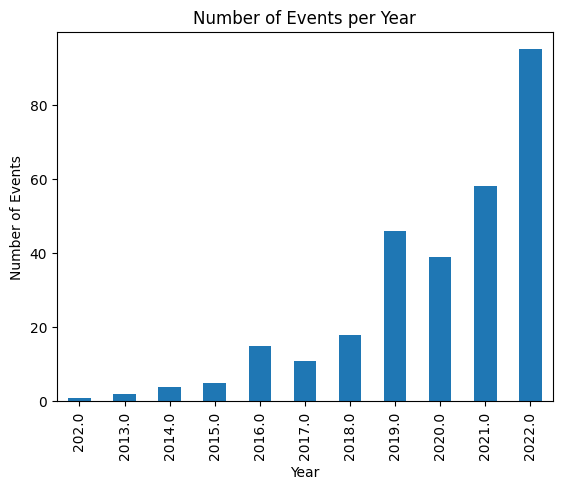

In [5]:
import matplotlib.pyplot as plt

events_per_year.plot(kind="bar", title="Number of Events per Year")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.show()

In [6]:
df2["Year"] = pd.to_numeric(df2["Year"], errors="coerce")

# Remove invalid years (like 202 or NaN)
df2 = df2[df2["Year"] >= 2013]
df2 = df2[df2["Year"] <= 2023]

# Convert to integer
df2["Year"] = df2["Year"].astype(int)

print(df2["Year"].unique())

[2022 2020 2021 2019 2018 2017 2016 2015 2014 2013]


In [7]:
events_per_year = df2.groupby("Year").size()
print(events_per_year)

Year
2013     2
2014     4
2015     5
2016    15
2017    11
2018    18
2019    46
2020    39
2021    58
2022    95
dtype: int64


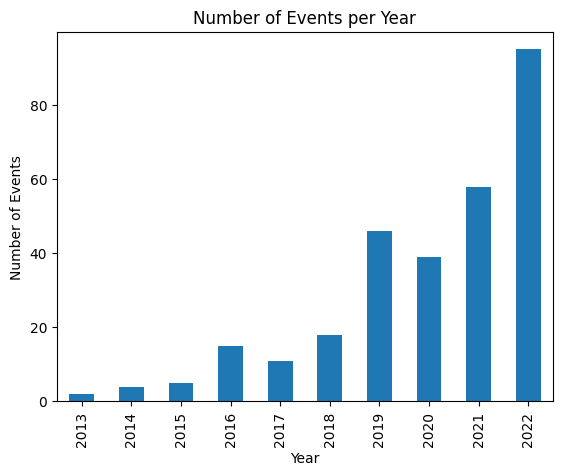

In [8]:
import matplotlib.pyplot as plt

events_per_year.plot(kind="bar", title="Number of Events per Year")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.show()

In [9]:
deaths_per_year = df2.groupby("Year")["Deaths"].sum()
print(deaths_per_year)

Year
2013      3.0
2014      6.0
2015      5.0
2016     16.0
2017     11.0
2018     21.0
2019     50.0
2020     47.0
2021     75.0
2022    118.0
Name: Deaths, dtype: float64


In [10]:
df2["Year"] = pd.to_numeric(df2["Year"], errors="coerce")
df2 = df2[(df2["Year"] >= 2013) & (df2["Year"] <= 2023)]
df2["Year"] = df2["Year"].astype(int)

In [11]:
deaths_per_year = df2.groupby("Year")["Deaths"].sum()
print(deaths_per_year)

Year
2013      3.0
2014      6.0
2015      5.0
2016     16.0
2017     11.0
2018     21.0
2019     50.0
2020     47.0
2021     75.0
2022    118.0
Name: Deaths, dtype: float64


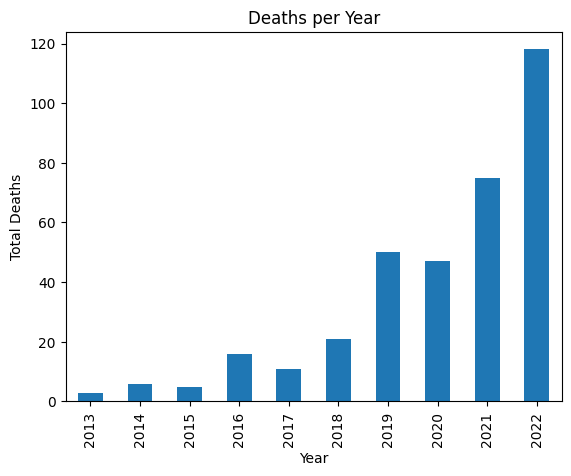

In [12]:
import matplotlib.pyplot as plt

deaths_per_year.plot(kind="bar", title="Deaths per Year")
plt.xlabel("Year")
plt.ylabel("Total Deaths")
plt.show()

In [13]:
country_counts = df2["Country"].value_counts()
print(country_counts)

Country
USA             214
China            16
Germany          11
Canada           10
Netherlands       6
UK                5
Norway            4
Switzerland       3
Taiwan            3
Holland           3
Australia         2
France            2
Denmark           2
Belgium           2
Japan             2
Mexico            1
Finland           1
Portugal          1
South Korea       1
Slovenia          1
Austria           1
Ukraine           1
Spain             1
Name: count, dtype: int64


In [14]:
print("Total Tesla driver deaths:", df2["Tesla_driver"].sum())

Total Tesla driver deaths:   1   1  -   1  -  -  -   1  -   1  -   1  -   1  -  -  -  -   1   1   1   1  -   1   1  -  -   1   1   1  -  -  -  -  -   1  -  -   1  -  -  -   1  -   1  -  -  -  -   1   1  -  -  -   1   1   1  -   1  -  -  -   1   1  -   1  -   1   1  -   1  -   1  -  -   1  -  -  -  -   1   1   1  -   1  -   1  -   1   1   1   1  -  -   1   1  -   1  -  -   1   1  -   1  -  -  -   1  -  -  -  -  -   1  -  -   1   1  -   1  -   1  -  -   1   1   1   1   1  -   1  -  -   1   1  -   1   1   1   1  -   1  -   1  -   1   1  -  -   1   1  -  -  -  -  -  -  -  -   1  -  -   1   1   1  -  -  -  -   1   1  -  -  -   1   1   1  -  -   1   1  -  -  -  -   1  -  -  -  -  -   1  -  -  -   1   1  -   1   1  -  -  -  -  -  -  -  -  -   1  -  -  -  -  -  -  -  -  -  -  -   1  -  -  -  -  -  -   1  -   1   1   1  -   1  -  -  -  -  -   1  -  -   1   1   1   1  -  -   1  -   1  -  -   1  -  -  -  -  -  -  -   1  -   1   1  -  -   1  -  -  -  -  -   1  -  -   1   1   1  -   1   1   1  -   

In [16]:
df2["Tesla_driver"] = pd.to_numeric(df2["Tesla_driver"], errors="coerce")

In [17]:
total_driver_deaths = df2["Tesla_driver"].sum()

print("Total Tesla driver deaths:", total_driver_deaths)

Total Tesla driver deaths: 117.0


In [18]:
df2["Tesla_occupant"] = pd.to_numeric(df2["Tesla_occupant"], errors="coerce")

occupant_events = df2["Tesla_occupant"].fillna(0) > 0

print("Proportion of occupant deaths:", occupant_events.mean())

Proportion of occupant deaths: 0.14675767918088736


In [19]:
df2["Cyclists__Peds"] = pd.to_numeric(df2["Cyclists__Peds"], errors="coerce")

cyclist_ped = df2["Cyclists__Peds"].fillna(0) > 0

print("Number of such events:", cyclist_ped.sum())
print("Proportion:", cyclist_ped.mean())

Number of such events: 43
Proportion: 0.14675767918088736


In [20]:
model_counts = df2["Model"].value_counts()
print(model_counts)

Model
-      181
S       45
 3      38
X       17
Y       10
 1       1
 2       1
Name: count, dtype: int64


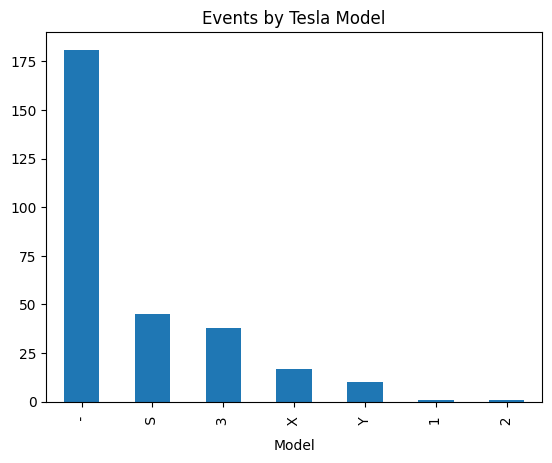

In [21]:
import matplotlib.pyplot as plt

model_counts.plot(kind="bar", title="Events by Tesla Model")
plt.show()

In [22]:
autopilot_deaths = pd.to_numeric(
    df2["Verified_Tesla_Autopilot_Deaths"],
    errors="coerce"
).sum()

print("Total verified autopilot deaths:", autopilot_deaths)

Total verified autopilot deaths: 19.0


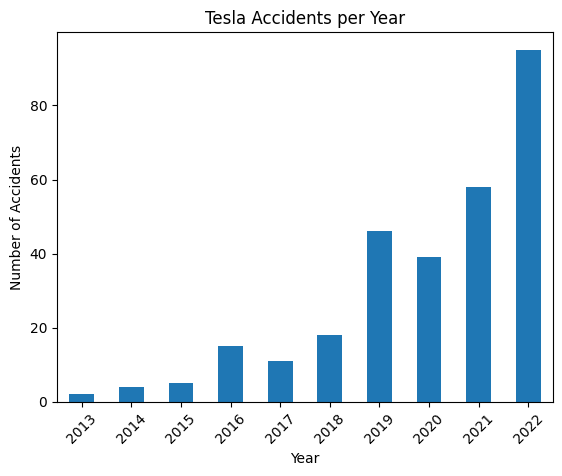

In [23]:
import matplotlib.pyplot as plt

events_per_year = df2.groupby("Year").size()

plt.figure()
events_per_year.plot(kind='bar')
plt.title("Tesla Accidents per Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)

plt.savefig("events_per_year.png")
plt.show()

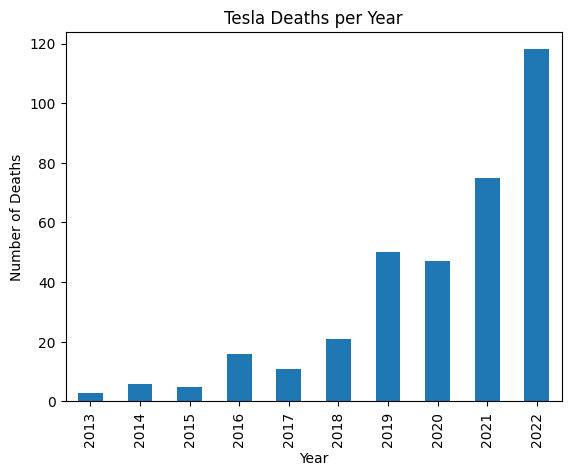

In [24]:
df2["Deaths"] = pd.to_numeric(df2["Deaths"], errors='coerce')

deaths_per_year = df2.groupby("Year")["Deaths"].sum()

plt.figure()
deaths_per_year.plot(kind='bar')
plt.title("Tesla Deaths per Year")
plt.xlabel("Year")
plt.ylabel("Number of Deaths")

plt.savefig("deaths_per_year.png")
plt.show()

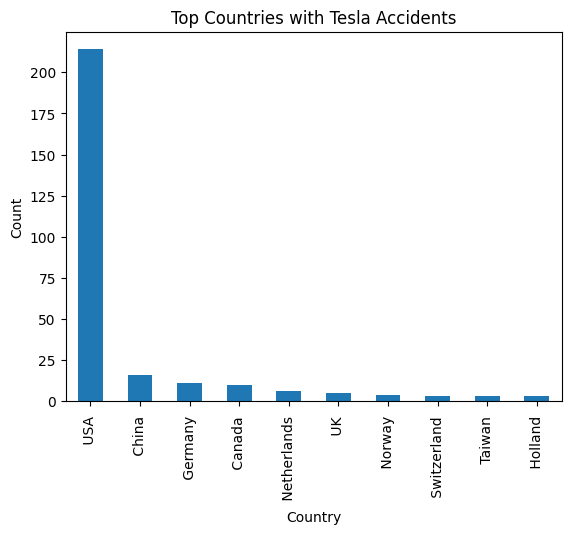

In [25]:
country_counts = df2["Country"].value_counts()

plt.figure()
country_counts.head(10).plot(kind='bar')
plt.title("Top Countries with Tesla Accidents")
plt.xlabel("Country")
plt.ylabel("Count")

plt.savefig("country_distribution.png")
plt.show()

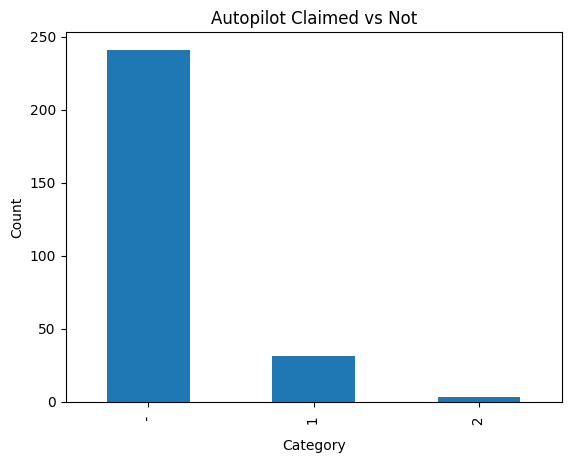

In [26]:
autopilot_counts = df2["Autopilot_claimed"].value_counts()

plt.figure()
autopilot_counts.plot(kind='bar')
plt.title("Autopilot Claimed vs Not")
plt.xlabel("Category")
plt.ylabel("Count")

plt.savefig("autopilot.png")
plt.show()

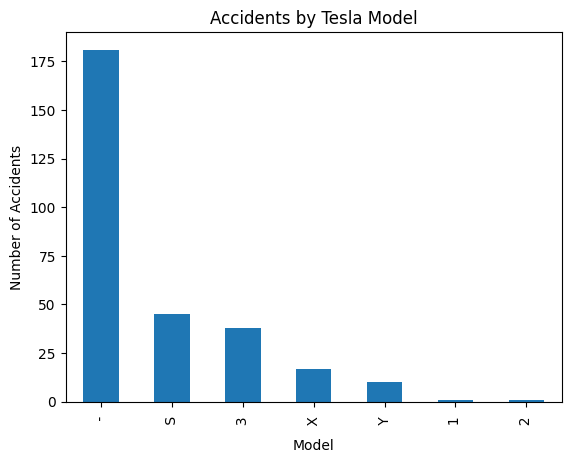

In [27]:
model_counts = df2["Model"].value_counts()

import matplotlib.pyplot as plt

plt.figure()
model_counts.plot(kind='bar')
plt.title("Accidents by Tesla Model")
plt.xlabel("Model")
plt.ylabel("Number of Accidents")

plt.savefig("model_distribution.png")
plt.show()

In [ ]:
print("Part 2 notebook is working")